# Performance Testing

## ideas
- TSTR (Train-Synthetic-Test-Real)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
real = pd.read_csv("og-transfer.csv")
synth = pd.read_csv("output/output.csv")

In [3]:
numeric_cols = real.select_dtypes(include=np.number).columns.intersection(
    synth.select_dtypes(include=np.number).columns
)

selected_cols = [
    'st_dirs',
    'st_successful',
    'st_failed',
    'st_expired',
    'st_canceled',
    'st_bytes_xfered',
    'st_faults'
]

# Ensure both datasets contain these columns
real = real[selected_cols].dropna()
synth = synth[selected_cols].dropna()

print(f"Validating {len(selected_cols)} transfer-related features.\n")

Validating 7 transfer-related features.



In [4]:
stats_real = real.describe().T[['mean', 'std', 'min', 'max']]
stats_synth = synth.describe().T[['mean', 'std', 'min', 'max']]

In [5]:
summary = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1
)
print("Descriptive statistics (real vs synthetic):")
print(summary)

Descriptive statistics (real vs synthetic):
                    mean_real      std_real  min_real      max_real  \
st_dirs          1.580000e-01  3.759237e-01       0.0  2.000000e+00   
st_successful    1.016400e+04  7.102875e+04       0.0  6.941380e+05   
st_failed        6.000000e-03  7.730428e-02       0.0  1.000000e+00   
st_expired       1.573026e+03  3.125476e+04       0.0  6.941380e+05   
st_canceled      6.519634e+03  5.415729e+04       0.0  5.445630e+05   
st_bytes_xfered  1.675242e+11  1.721170e+12       0.0  3.146001e+13   
st_faults        3.476768e+03  2.337198e+04       0.0  4.429300e+05   

                   mean_synth     std_synth  min_synth     max_synth  
st_dirs          1.580000e-01  3.651063e-01        0.0  1.000000e+00  
st_successful    5.378000e+01  6.321803e+02        0.0  1.326900e+04  
st_failed        0.000000e+00  0.000000e+00        0.0  0.000000e+00  
st_expired       1.160000e-01  3.267377e-01        0.0  2.000000e+00  
st_canceled      8.120000e-01  5

In [6]:
synth.loc[synth["st_bytes_xfered"] > real["st_bytes_xfered"].max(), "st_bytes_xfered"] = real["st_bytes_xfered"].max()

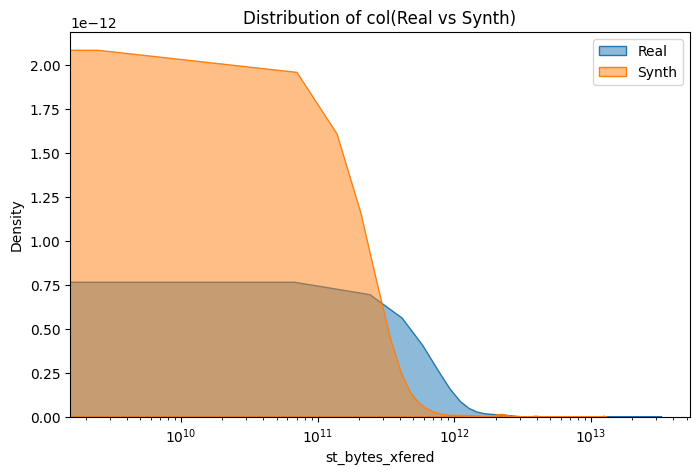

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
 
# Plot the distributions
col = "st_bytes_xfered"
plt.figure(figsize=(8, 5))

sns.kdeplot(real[col], label="Real", fill=True, alpha=0.5)

sns.kdeplot(synth[col], label="Synth", fill=True, alpha=0.5)
plt.xscale("log")
 
plt.title("Distribution of col(Real vs Synth)")

plt.xlabel(col)

plt.ylabel("Density")

plt.legend()

plt.show()

 

In [8]:
ks_results, wd_results = {}, {}
for col in selected_cols:
    ks = ks_2samp(real[col], synth[col]).statistic
    wd = wasserstein_distance(real[col], synth[col])
    ks_results[col] = ks
    wd_results[col] = wd

ks_df = pd.DataFrame({'KS_stat': ks_results, 'Wasserstein': wd_results})
print("\nDistribution similarity (lower is better):")
print(ks_df.sort_values('KS_stat'))


Distribution similarity (lower is better):
                 KS_stat   Wasserstein
st_dirs            0.004  8.000000e-03
st_failed          0.006  6.000000e-03
st_expired         0.024  1.572910e+03
st_successful      0.052  1.011031e+04
st_canceled        0.056  6.518850e+03
st_faults          0.082  2.722720e+05
st_bytes_xfered    0.100  9.145721e+10


/Users/kafka/Desktop/research/gmm-synth-transfer/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


In [11]:
print("real")
print(np.percentile(real.st_bytes_xfered, 99))
print(np.percentile(real.st_bytes_xfered, 95))
print(np.percentile(real.st_bytes_xfered, 90))
print("synth")
print(np.percentile(synth.st_bytes_xfered, 99))
print(np.percentile(synth.st_bytes_xfered, 95))
print(np.percentile(synth.st_bytes_xfered, 90))

# clipping or re-drawing

real
2097819266805.6895
333207077273.598
21474941337.6
synth
2084435053373.5596
333058158425.75
21487551139.300007


In [15]:
corr_real = real.corr()
corr_synth = synth.corr()

# Drop columns that annihilate correlation
zero_var = real.columns[(real.nunique() <= 1) | (synth.nunique() <= 1)]
real_corr_input = real.drop(columns=zero_var)
synth_corr_input = synth.drop(columns=zero_var)
corr_real = real_corr_input.corr()
corr_synth = synth_corr_input.corr()
corr_diff = np.linalg.norm(corr_real - corr_synth, 'fro')

corr_diff_matrix = (corr_real - corr_synth).abs()

# Flatten to pairs for readability
corr_diff_pairs = (
    corr_diff_matrix
    .where(np.triu(np.ones(corr_diff_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_diff_pairs.columns = ['Feature1', 'Feature2', 'Abs_Diff']

# Sort by difference magnitude
corr_diff_pairs = corr_diff_pairs.sort_values('Abs_Diff', ascending=False)
print("Top correlation differences:")
print(corr_diff)
print(corr_diff_pairs.head(10))


Top correlation differences:
0.7346703259238723
           Feature1         Feature2  Abs_Diff
6     st_successful      st_canceled  0.340446
14  st_bytes_xfered        st_faults  0.276604
1           st_dirs       st_expired  0.132819
13      st_canceled        st_faults  0.124729
7     st_successful  st_bytes_xfered  0.107996
8     st_successful        st_faults  0.099938
0           st_dirs    st_successful  0.071186
5     st_successful       st_expired  0.068462
3           st_dirs  st_bytes_xfered  0.059360
9        st_expired      st_canceled  0.047828
